# Chapter 12: neural networks that write like Shakespeare: recurrent layers for variable-length data

Haikal Ali TK-46-GAB 1103223071

## In this chapter

- The challenge of arbitrary length
- The surprising power of averaged word vectors
- The limitations of bag-of-words vectors
- Using identity vectors to sum word embeddings
- Learning the transition matrices
- Learning to create useful sentence vectors
- Forward propagation in Python
- Forward propagation and backpropagation with arbitrary length
- Weight update with arbitrary length

## The challenge of arbitrary length

Chapter ini melanjutkan intuisi dari chapter 11 tentang word embedding. Jika word embedding dapat menyimpan makna satu kata, maka chapter ini membahas cara membuat embedding yang menyimpan makna phrase atau sentence dengan panjang yang bervariasi.

Masalah utamanya adalah sequence dapat memiliki panjang berbeda. Cara paling sederhana adalah menggabungkan atau menumpuk word embeddings. Namun, pendekatan ini membuat sentence vector memiliki panjang berbeda-beda.

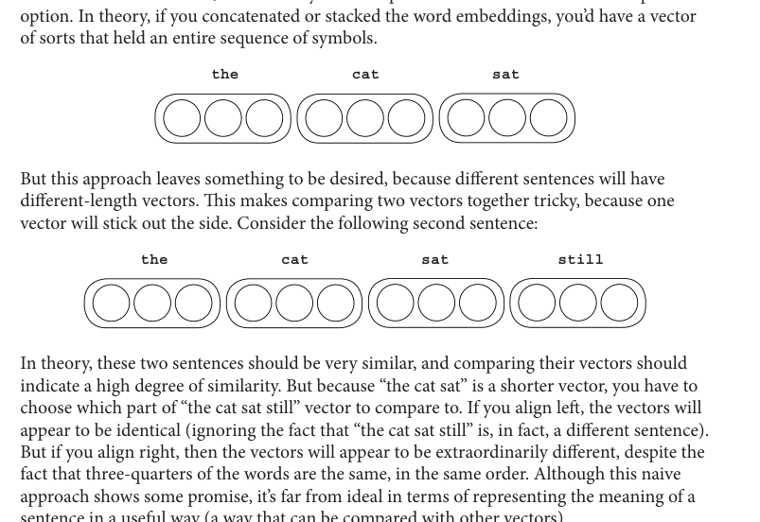

Contohnya, sentence `the cat sat` lebih pendek daripada `the cat sat still`. Keduanya mirip, tetapi jika embeddings digabung begitu saja, cara membandingkannya menjadi sulit karena panjang vector berbeda.

Jika alignment dibuat dari kiri, keduanya terlihat hampir identik. Jika alignment dibuat dari kanan, keduanya terlihat sangat berbeda. Karena itu, concatenation belum ideal untuk merepresentasikan makna sentence dalam vector yang dapat dibandingkan.

## Do comparisons really matter?

Perbandingan dua vectors penting karena memberi gambaran tentang apa yang dilihat neural network.

Jika metode pembuatan sentence vectors tidak merefleksikan similarity antara dua sentences, maka network juga akan kesulitan mengenali bahwa dua sentences tersebut mirip. Network hanya bekerja dengan vectors.

Tujuan chapter ini adalah membuat sentence vectors yang berguna untuk prediction. Minimal, sentences yang mirip perlu menghasilkan vectors yang mirip juga.

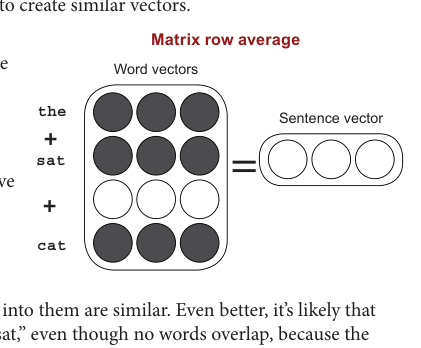

Pendekatan berikutnya adalah mengambil vector dari setiap word dalam sentence, lalu merata-ratakannya. Dengan average, setiap sentence vector memiliki panjang sama.

Sentence `the cat sat` dan `the cat sat still` akan memiliki vectors yang mirip karena word embeddings yang menyusunnya mirip. Bahkan `a dog walked` bisa saja mirip dengan `the cat sat` jika words yang digunakan memiliki embedding yang juga mirip.

## The surprising power of averaged word vectors

Average word vectors adalah tool yang kuat untuk neural prediction.

Dengan menggunakan embeddings dari chapter 11, setiap review dapat diubah menjadi vector rata-rata dari word embeddings yang ada di dalam review tersebut. Setelah itu, similarity antar review dapat dihitung dengan dot product.

In [1]:
# Cell ini memakai variabel dari Chapter 11 jika sudah tersedia:
# weights_0_1, word2index, tokens, raw_reviews.
# Jika belum tersedia, cell ini akan dilewati.

from collections import Counter
import numpy as np

if all(name in globals() for name in ["weights_0_1", "word2index", "tokens", "raw_reviews"]):
  norms = np.sum(weights_0_1 * weights_0_1, axis=1)
  norms.resize(norms.shape[0], 1)
  normed_weights = weights_0_1 * norms

  def make_sent_vect(words):
    indices = list(
      map(
        lambda x: word2index[x],
        filter(lambda x: x in word2index, words)
      )
    )
    return np.mean(normed_weights[indices], axis=0)

  reviews2vectors = []

  for review in tokens:
    reviews2vectors.append(make_sent_vect(review))

  reviews2vectors = np.array(reviews2vectors)

  def most_similar_reviews(review):
    v = make_sent_vect(review)
    scores = Counter()

    for i, val in enumerate(reviews2vectors.dot(v)):
      scores[i] = val

    most_similar = []

    for idx, score in scores.most_common(3):
      most_similar.append(raw_reviews[idx][0:40])

    return most_similar

  print(most_similar_reviews(["boring", "awful"]))
else:
  print("Variabel Chapter 11 belum tersedia. Jalankan notebook Chapter 11 terlebih dahulu untuk eksperimen average review vectors.")

Variabel Chapter 11 belum tersedia. Jalankan notebook Chapter 11 terlebih dahulu untuk eksperimen average review vectors.


Chapter menunjukkan bahwa query average vector dari words `boring` dan `awful` dapat mengembalikan reviews yang sangat negatif. Artinya, ada informasi statistik menarik dalam vectors tersebut, sehingga negative dan positive embeddings dapat membentuk cluster.

## How is information stored in these embeddings?

Saat word embeddings dirata-ratakan, average shapes tetap tersimpan.

Word vector dapat dibayangkan sebagai garis bergelombang. Setiap posisi dalam vector memiliki nilai tinggi atau rendah. Words dengan makna yang mirip cenderung memiliki bentuk gelombang yang mirip.

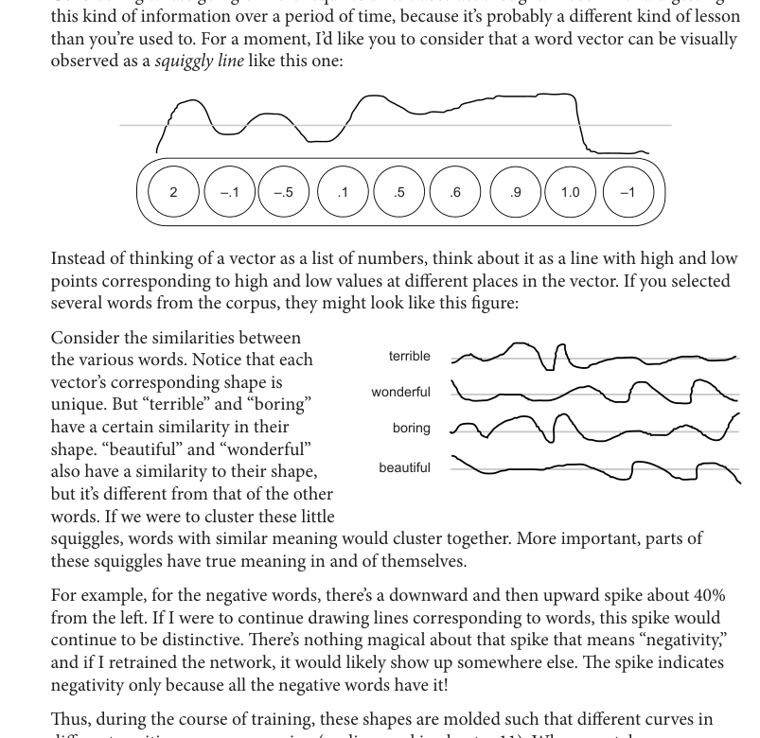

Misalnya, `terrible` dan `boring` memiliki kemiripan bentuk. `beautiful` dan `wonderful` juga memiliki kemiripan bentuk, tetapi berbeda dari kelompok negative words.

Bagian tertentu dari gelombang dapat memiliki makna karena muncul konsisten pada words dengan karakteristik yang sama. Tidak ada posisi yang secara intrinsik berarti “negativity”; posisi tersebut berarti demikian karena semua negative words memiliki pola serupa di sana.

Saat sentence vector dibuat dengan average dari word embeddings, makna dominan dari sentence tetap tersimpan, sementara noise dari word individual cenderung saling merata.

## How does a neural network use embeddings?

Neural network menggunakan embeddings seperti menggunakan dataset lain: mencari correlation antara bentuk input dan target label.

Bagian-bagian naik-turun pada embedding dapat berkorelasi dengan label tertentu. Selama training, network membentuk karakteristik khusus pada embeddings agar dapat membedakan words dan mengelompokkan words yang berguna untuk prediction.

Namun, average sentence embedding memiliki kelemahan. Jika terlalu banyak words disimpan dalam satu fixed-length vector, maka banyak pola dapat saling merata sampai vector menjadi hampir datar. Dengan kata lain, information tidak decay dengan rapi. Terlalu banyak words dalam satu average vector dapat membuat hampir tidak ada informasi tersisa.

## The limitations of bag-of-words vectors

Kelemahan terbesar average embeddings adalah tidak memahami urutan.

Sentence `Yankees defeat Red Sox` dan `Red Sox defeat Yankees` akan menghasilkan vector yang sama jika embeddings hanya dirata-ratakan, padahal maknanya berlawanan. Sentence seperti `Sox Red Yankees defeat` juga akan menghasilkan embedding yang sama.

Pendekatan menjumlahkan atau merata-ratakan embeddings disebut **bag-of-words**, karena order tidak disimpan. Karena addition associative, urutan words tidak mengubah vector akhir.

Chapter ini berfokus pada membuat sentence vectors yang memperhitungkan order. Salah satu cara terkenal untuk membuat vectors bagi sequences adalah **recurrent neural network (RNN)**.

Sebelum masuk ke RNN, chapter memperkenalkan identity matrix. Identity matrix adalah square matrix berisi 0, dengan angka 1 pada diagonal dari kiri atas ke kanan bawah.

Tujuan identity matrix adalah: jika sebuah vector dikalikan dengan identity matrix, hasilnya tetap vector yang sama.

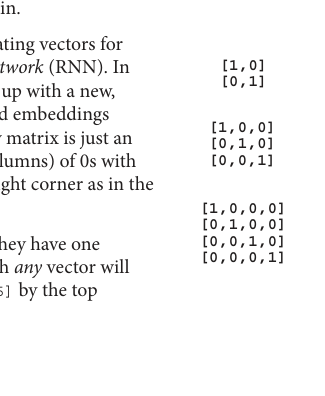

## Using identity vectors to sum word embeddings

Identity matrix digunakan sebagai alat bantu untuk membuat cara baru menjumlahkan embeddings.

Pada penjumlahan biasa, sentence embedding dibuat dengan menjumlahkan embeddings semua words. Pada pendekatan baru, di antara setiap sum ditambahkan vector-matrix multiplication dengan identity matrix.

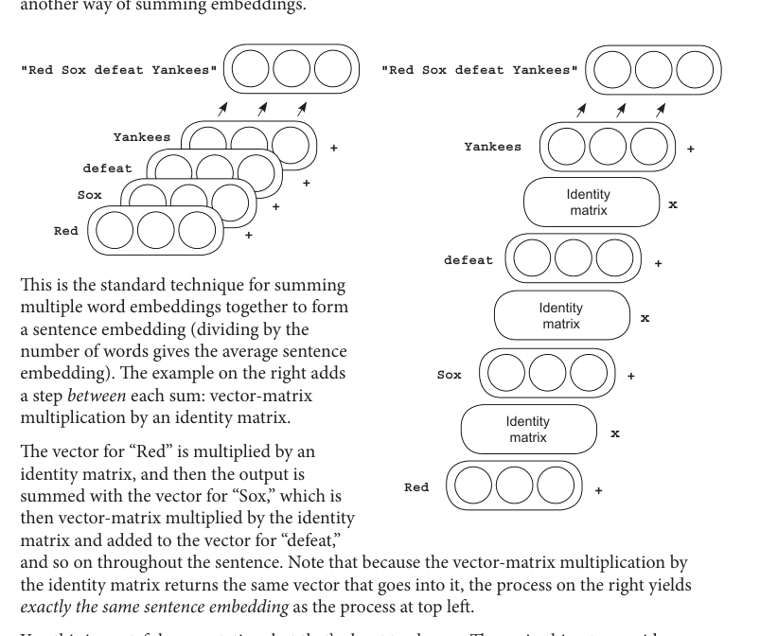

Vector untuk `Red` dikalikan identity matrix, lalu ditambah vector `Sox`. Hasilnya dikalikan identity matrix lagi, lalu ditambah vector `defeat`, dan seterusnya.

Karena identity matrix mengembalikan vector yang sama, hasil akhirnya tetap sama seperti penjumlahan biasa. Namun, jika matrix yang digunakan bukan identity matrix, urutan words akan memengaruhi embedding akhir.

## Matrices that change absolutely nothing

Kode berikut menunjukkan identity matrix di Python.

In [2]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([0.1, 0.2, 0.3])
c = np.array([-1, -0.5, 0])
d = np.array([0, 0, 0])

identity = np.eye(3)

print(identity)
print(a.dot(identity))
print(b.dot(identity))
print(c.dot(identity))
print(d.dot(identity))

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[1. 2. 3.]
[0.1 0.2 0.3]
[-1.  -0.5  0. ]
[0. 0. 0.]


Dua cara berikut menghasilkan sentence embedding yang sama karena `identity` tidak mengubah vector.

In [3]:
this = np.array([2, 4, 6])
movie = np.array([10, 10, 10])
rocks = np.array([1, 1, 1])

print(this + movie + rocks)
print((this.dot(identity) + movie).dot(identity) + rocks)

[13 15 17]
[13. 15. 17.]


Identity matrix adalah satu-satunya matrix yang dijamin mengembalikan vector yang sama setelah vector-matrix multiplication.

## Learning the transition matrices

Jika identity matrices boleh berubah untuk meminimalkan loss, maka network dapat belajar transition matrix.

Tujuannya adalah membuat sentence embeddings yang memperhatikan order. Pada pendekatan sum biasa, `Red Sox defeat Yankees` dan `Yankees defeat Red Sox` menghasilkan vector yang sama. Jika identity matrix diganti dengan matrix yang dipelajari, urutan words akan menghasilkan vector berbeda.

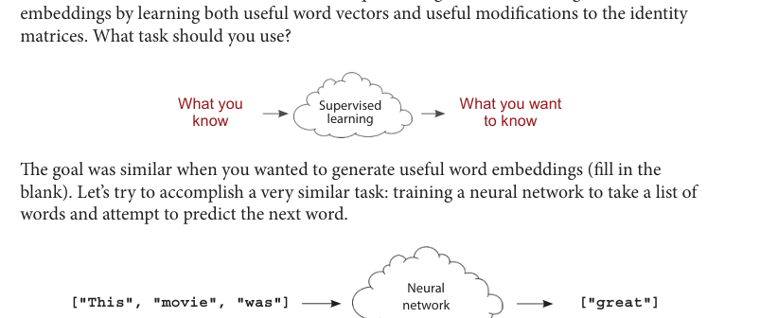

Pertanyaannya adalah: matrix apa yang harus digunakan selain identity matrix? Jawaban deep learning adalah: matrix tersebut dipelajari seperti matrix lain dalam neural network.

Task yang digunakan adalah memprediksi next word. Network menerima list words dan mencoba memprediksi word berikutnya.

Contoh:

`["This", "movie", "was"] -> ["great"]`

## Learning to create useful sentence vectors

Network membuat sentence embedding, memakai embedding itu untuk memprediksi next word, lalu memodifikasi bagian-bagian yang membentuk sentence embedding agar prediction lebih akurat.

Input network adalah phrase seperti `Red Sox defeat`, dan target word yang diprediksi adalah `Yankees`.

Matrix di antara word vectors awalnya identity matrix, tetapi selama training akan diperbarui. Dengan begitu, network belajar cara memasukkan informasi order ke dalam sentence embedding.

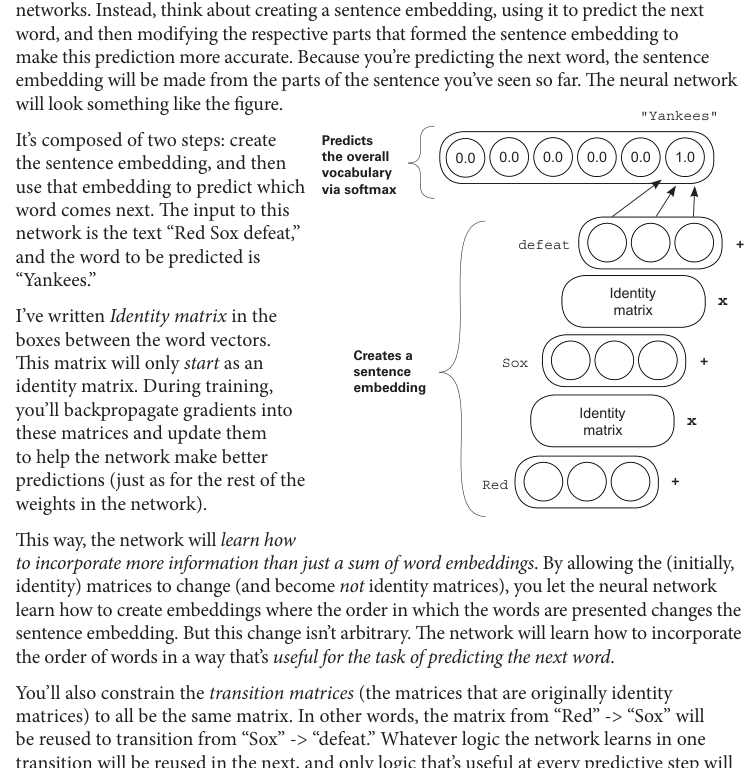

Transition matrices dibatasi agar semuanya memakai matrix yang sama. Artinya, matrix dari `Red -> Sox` dipakai ulang juga untuk `Sox -> defeat`. Logic transition yang dipelajari pada satu posisi akan dipakai ulang di posisi lain.

## Forward propagation in Python

Kode berikut membuat toy version forward propagation dengan vocabulary terbatas sembilan words.

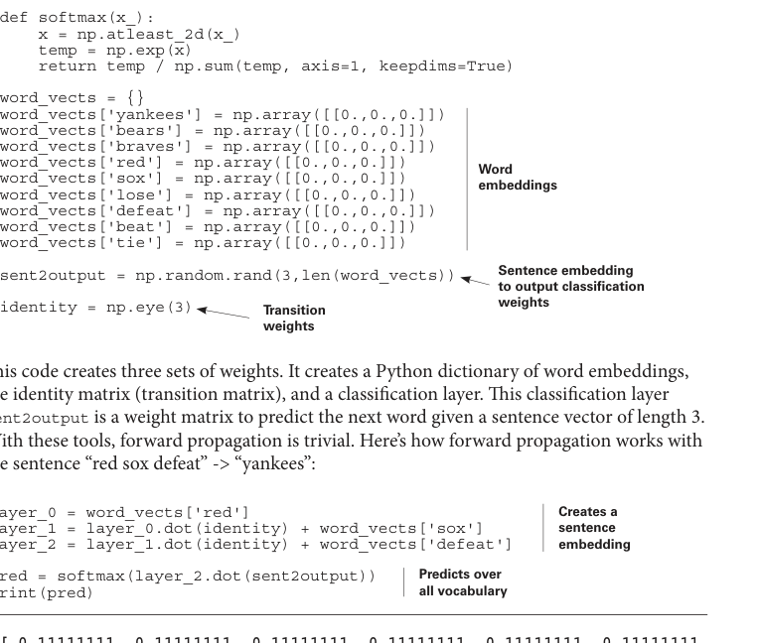

In [4]:
import numpy as np

def softmax(x_):
  x = np.atleast_2d(x_)
  temp = np.exp(x)
  return temp / np.sum(temp, axis=1, keepdims=True)

word_vects = {}
word_vects["yankees"] = np.array([[0., 0., 0.]])
word_vects["bears"] = np.array([[0., 0., 0.]])
word_vects["braves"] = np.array([[0., 0., 0.]])
word_vects["red"] = np.array([[0., 0., 0.]])
word_vects["sox"] = np.array([[0., 0., 0.]])
word_vects["lose"] = np.array([[0., 0., 0.]])
word_vects["defeat"] = np.array([[0., 0., 0.]])
word_vects["beat"] = np.array([[0., 0., 0.]])
word_vects["tie"] = np.array([[0., 0., 0.]])

sent2output = np.random.rand(3, len(word_vects))
identity = np.eye(3)

layer_0 = word_vects["red"]
layer_1 = layer_0.dot(identity) + word_vects["sox"]
layer_2 = layer_1.dot(identity) + word_vects["defeat"]

pred = softmax(layer_2.dot(sent2output))

print(pred)

[[0.11111111 0.11111111 0.11111111 0.11111111 0.11111111 0.11111111
  0.11111111 0.11111111 0.11111111]]


Karena semua word embeddings awal bernilai 0, prediction softmax awal menjadi uniform untuk semua vocabulary.

## How do you backpropagate into this?

Backpropagation pada struktur ini memakai langkah yang sama seperti sebelumnya.

Ketika dua vectors dijumlahkan pada forward propagation, gradient yang sama dibackpropagate ke kedua sisi penjumlahan. Setelah `layer_2_delta` dibuat, delta dibackpropagate ke `layer_1` melalui identity matrix dan juga ke word vector `defeat`.

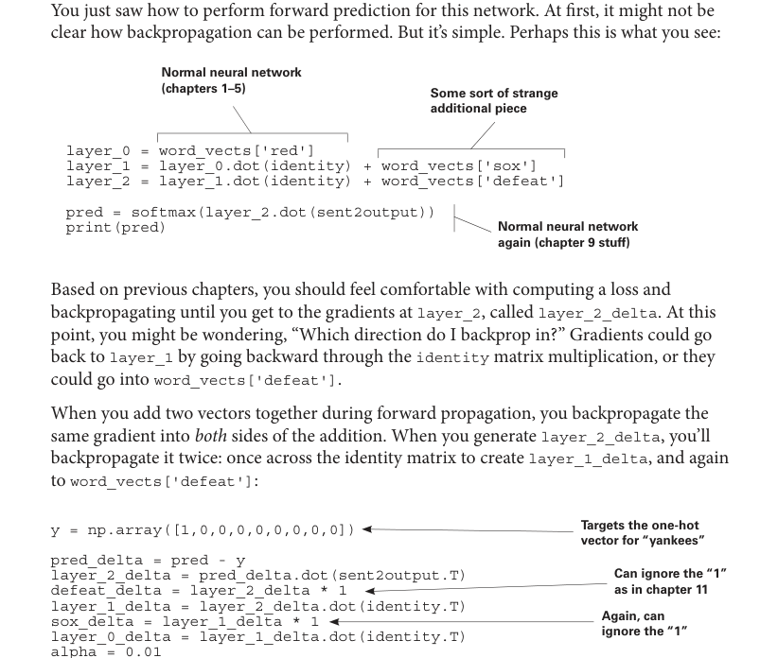

In [5]:
vocab_list = list(word_vects.keys())
y = np.zeros((1, len(vocab_list)))
y[0, vocab_list.index("yankees")] = 1

pred_delta = pred - y
layer_2_delta = pred_delta.dot(sent2output.T)

defeat_delta = layer_2_delta * 1
layer_1_delta = layer_2_delta.dot(identity.T)

sox_delta = layer_1_delta * 1
layer_0_delta = layer_1_delta.dot(identity.T)

alpha = 0.01

word_vects["red"] -= layer_0_delta * alpha
word_vects["sox"] -= sox_delta * alpha
word_vects["defeat"] -= defeat_delta * alpha

identity -= np.outer(layer_0, layer_1_delta) * alpha
identity -= np.outer(layer_1, layer_2_delta) * alpha
sent2output -= np.outer(layer_2, pred_delta) * alpha

print("Updated red:", word_vects["red"])
print("Updated sox:", word_vects["sox"])
print("Updated defeat:", word_vects["defeat"])

Updated red: [[-0.00436421 -0.00030998 -0.00219718]]
Updated sox: [[-0.00436421 -0.00030998 -0.00219718]]
Updated defeat: [[-0.00436421 -0.00030998 -0.00219718]]


## Let’s train it!

Chapter memakai Babi dataset untuk toy task. Dataset ini adalah synthetic question-answer corpus yang berisi statements dan questions sederhana.

Dataset diunduh dengan perintah dari buku, lalu file `qa1_single-supporting-fact_train.txt` dibaca dan dibersihkan. Pada chapter ini, dataset tidak dipakai untuk QA, tetapi dipakai untuk melatih network menyelesaikan sentence dengan memprediksi next word.

In [8]:
# Perintah dari buku untuk mengambil Babi dataset.
!wget -q http://www.thespermwhale.com/jaseweston/babi/tasks_1-20_v1-1.tar.gz
!tar -xzf tasks_1-20_v1-1.tar.gz

tar (child): tasks_1-20_v1-1.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now


In [7]:
import sys
import random
import math
from collections import Counter
import numpy as np
from pathlib import Path

dataset_path = Path("tasksv11/en/qa1_single-supporting-fact_train.txt")

if not dataset_path.exists():
  raise FileNotFoundError(
    "Dataset Babi belum ditemukan. Jalankan cell download dan extract terlebih dahulu."
  )

with open(dataset_path, "r", encoding="utf-8") as f:
  raw = f.readlines()

tokens = []

for line in raw[0:1000]:
  tokens.append(line.lower().replace("\n", "").split(" ")[1:])

print(tokens[0:3])

FileNotFoundError: Dataset Babi belum ditemukan. Jalankan cell download dan extract terlebih dahulu.

## Setting things up

Sebelum membuat matrices, jumlah parameters perlu diketahui.

Langkah berikut membuat vocabulary, `word2index`, function `words2indices`, dan `softmax`. Kemudian dibuat word embeddings, recurrent matrix, start embedding, decoder matrix, dan one-hot utility matrix.

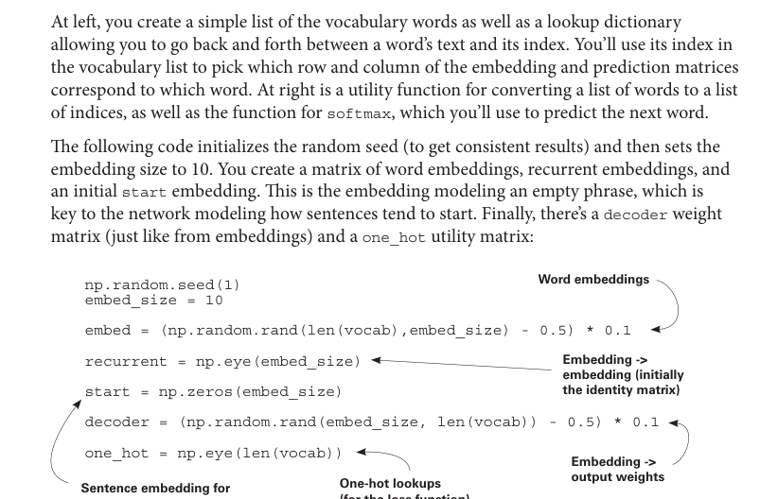

In [ ]:
vocab = set()

for sent in tokens:
  for word in sent:
    vocab.add(word)

vocab = list(vocab)

word2index = {}

for i, word in enumerate(vocab):
  word2index[word] = i

def words2indices(sentence):
  idx = []

  for word in sentence:
    idx.append(word2index[word])

  return idx

def softmax(x):
  e_x = np.exp(x - np.max(x))
  return e_x / e_x.sum(axis=0)

np.random.seed(1)

embed_size = 10

embed = (np.random.rand(len(vocab), embed_size) - 0.5) * 0.1
recurrent = np.eye(embed_size)
start = np.zeros(embed_size)
decoder = (np.random.rand(embed_size, len(vocab)) - 0.5) * 0.1
one_hot = np.eye(len(vocab))

print("Vocab size:", len(vocab))
print("Embed shape:", embed.shape)
print("Recurrent shape:", recurrent.shape)
print("Decoder shape:", decoder.shape)

## Forward propagation with arbitrary length

Forward propagation dilakukan dengan logic yang sama, tetapi sequence memiliki panjang bebas.

Karena panjang `sent` bisa berbeda, layer tidak lagi dibuat sebagai variabel statis. Setiap timestep dimasukkan ke list `layers`.

In [ ]:
def predict(sent):
  layers = []

  layer = {}
  layer["hidden"] = start
  layers.append(layer)

  loss = 0

  for target_i in range(len(sent)):
    layer = {}
    layer["pred"] = softmax(layers[-1]["hidden"].dot(decoder))

    loss += -np.log(layer["pred"][sent[target_i]])

    layer["hidden"] = layers[-1]["hidden"].dot(recurrent) + embed[sent[target_i]]

    layers.append(layer)

  return layers, loss

Pada setiap timestep, network memprediksi next term dari hidden state sebelumnya. Setelah itu hidden state baru dibuat dengan recurrent matrix dan embedding word saat ini.

## Backpropagation with arbitrary length

Backpropagation dilakukan dari layer terakhir ke layer pertama.

Untuk setiap layer, output gradient dibuat dari prediction terhadap one-hot target. Delta hidden state kemudian dibackpropagate ke layer sebelumnya melalui recurrent matrix.

In [ ]:
# Contoh satu forward + backprop tanpa update, agar struktur data terlihat.

sent = words2indices(tokens[0][1:])
layers, loss = predict(sent)

for layer_idx in reversed(range(len(layers))):
  layer = layers[layer_idx]
  target = sent[layer_idx - 1]

  if layer_idx > 0:
    layer["output_delta"] = layer["pred"] - one_hot[target]
    new_hidden_delta = layer["output_delta"].dot(decoder.transpose())

    if layer_idx == len(layers) - 1:
      layer["hidden_delta"] = new_hidden_delta
    else:
      layer["hidden_delta"] = new_hidden_delta + layers[layer_idx + 1]["hidden_delta"].dot(recurrent.transpose())
  else:
    layer["hidden_delta"] = layers[layer_idx + 1]["hidden_delta"].dot(recurrent.transpose())

print("Loss:", loss)
print("Jumlah layers:", len(layers))
print("Hidden delta layer 0 shape:", layers[0]["hidden_delta"].shape)

## Weight update with arbitrary length

Setelah delta dihitung, weights diperbarui.

`start`, `decoder`, `embed`, dan `recurrent` semuanya di-update menggunakan gradients. Update dibagi dengan panjang sentence agar skala update tidak terlalu bergantung pada panjang sequence.

In [ ]:
for iter in range(30000):
  alpha = 0.001
  sent = words2indices(tokens[iter % len(tokens)][1:])

  layers, loss = predict(sent)

  for layer_idx in reversed(range(len(layers))):
    layer = layers[layer_idx]
    target = sent[layer_idx - 1]

    if layer_idx > 0:
      layer["output_delta"] = layer["pred"] - one_hot[target]
      new_hidden_delta = layer["output_delta"].dot(decoder.transpose())

      if layer_idx == len(layers) - 1:
        layer["hidden_delta"] = new_hidden_delta
      else:
        layer["hidden_delta"] = new_hidden_delta + layers[layer_idx + 1]["hidden_delta"].dot(recurrent.transpose())
    else:
      layer["hidden_delta"] = layers[layer_idx + 1]["hidden_delta"].dot(recurrent.transpose())

  start -= layers[0]["hidden_delta"] * alpha / float(len(sent))

  for layer_idx, layer in enumerate(layers[1:]):
    decoder -= np.outer(layers[layer_idx]["hidden"], layer["output_delta"]) * alpha / float(len(sent))

    embed_idx = sent[layer_idx]
    embed[embed_idx] -= layers[layer_idx]["hidden_delta"] * alpha / float(len(sent))

    recurrent -= np.outer(layers[layer_idx]["hidden"], layer["hidden_delta"]) * alpha / float(len(sent))

  if iter % 1000 == 0:
    print("Perplexity:" + str(np.exp(loss / len(sent))))

## Execution and output analysis

Metric yang ditampilkan adalah **perplexity**. Perplexity tinggi berarti probability distribution prediction belum cocok dengan distribution yang benar. Perplexity rendah dan mendekati 1 berarti prediction semakin cocok.

Jika perplexity menurun, network sedang belajar memprediksi probabilities yang lebih sesuai dengan data.

In [ ]:
sent_index = 4

l, _ = predict(words2indices(tokens[sent_index]))

print(tokens[sent_index])

for i, each_layer in enumerate(l[1:-1]):
  input_word = tokens[sent_index][i]
  true = tokens[sent_index][i + 1]
  pred = vocab[each_layer["pred"].argmax()]

  print(
    "Prev Input:" + input_word + (" " * (12 - len(input_word))) +
    "True:" + true + (" " * (15 - len(true))) +
    "Pred:" + pred
  )

Melihat predictions membantu memahami pola yang dipelajari network. Pada awal training, output cenderung random. Setelah training, network sering belajar words umum seperti `the`, lalu mulai belajar pola yang lebih spesifik seperti phrase `to the`.

Task ini hampir tidak mungkin dipelajari sempurna karena context yang diberikan tidak selalu cukup untuk memprediksi next word secara unik.

## Summary

Chapter ini membahas recurrent neural networks untuk arbitrary-length sequences.

Sequence dengan panjang bebas tidak cocok direpresentasikan dengan concatenation biasa karena panjang vector berbeda. Average word embeddings dapat membuat fixed-length vector, tetapi kehilangan order. Identity matrix digunakan sebagai langkah perantara untuk menunjukkan bahwa order dapat memengaruhi embedding jika matrix transition dipelajari.

RNN membuat hidden state yang diperbarui di setiap timestep dengan recurrent matrix yang sama. Network dilatih untuk memprediksi next word, lalu backpropagation dilakukan sepanjang sequence. Sentence vector tidak menyimpan semua informasi; RNN juga belajar apa yang perlu diingat dan apa yang perlu dilupakan.